# Actividad - Proyecto práctico

> Actividad en grupos de 4 alumnos. Nombres en orden alfabético (de apellidos):

*   **Alumno 1:** Vara Rodríguez, Jorge
*   **Alumno 2:** Larios Pérez, José María
*   **Alumno 3:** Fernández Gordo, Javier
*   **Alumno 4:** Carvajal Benítez, Pablo

**Entorno:** `SpaceInvaders-v0` · **Algoritmo:** DQN (Stable-Baselines3) · **Requisito mínimo:** media de recompensa en modo test por encima del umbral indicado en el listado del grupo.


# Proyecto 10 - DQN con Stable-Baselines3

Entrenamiento de un agente DQN para `SpaceInvaders-v0` usando Stable-Baselines3.

El notebook mantiene la idea de la práctica anterior:

- imágenes de entrada de 84x84,
- pila de 4 frames,
- red convolucional tipo DQN Atari,
- recompensa clipped,
- conteo de episodios consecutivos con recompensa clipped superior a 20,
- guardado de métricas completas en CSV/JSON, TensorBoard y guardado manual del modelo.


In [ ]:
# ============================
# 1. Instalación de librerías
# ============================

# Instalación completa para usar SpaceInvaders-v0 con Gym clásico

%pip install gym==0.17.3
%pip install git+https://github.com/Kojoley/atari-py.git
%pip install stable-baselines3==0.10.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 78.0 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.17.3-py3-none-any.whl size=1654617 sha256=0b5e6520baaf7a136e63263f1b39b2976e202d04f4f03d4a54b66d3a3d7ecc48
  Stored in directory: /root/.cache/pip/wheels/99/7e/03/69cdeb432380e05bc9a56ff68451d8063e41aa06db508f4be5
Successfully built gym
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.2
    Uninstalling cloudpickle-3.1.2:
      Successfully uninstalled cloudpickle-3.1.2
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.42.0 requires cloudpickl

In [ ]:
import gym
from stable_baselines3 import DQN

ENV_ID = "SpaceInvaders-v0"
env = gym.make(ENV_ID)

print("Gym OK")
print("SB3 DQN OK")

Gym OK
SB3 DQN OK


In [ ]:
# ============================
# 2. Imports
# ============================

from pathlib import Path
import json
import time
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gym
import torch as th
import torch.nn as nn

from google.colab import drive

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor


In [ ]:
# ============================
# 3. Google Drive y rutas
# ============================

drive.mount('/content/gdrive')

drive_root = '/content/gdrive/My Drive/08_MIAR/sb3/conlogs'
PROJECT_NAME = 'sb3_1_spaceinvaders_v0'

OUTPUT_DIR = Path(drive_root) / 'datos' / PROJECT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modelos
MODEL_LATEST = OUTPUT_DIR / 'dqn_spaceinvaders_v0_sb3_latest.zip'
POLICY_LATEST = OUTPUT_DIR / 'dqn_spaceinvaders_v0_policy_latest.pt'

# Logs completos propios
LOG_FILENAME = OUTPUT_DIR / 'dqn_SpaceInvaders-v0_sb3_log.json'
CSV_LOG_FILENAME = OUTPUT_DIR / 'dqn_SpaceInvaders-v0_sb3_log.csv'

# Logs oficiales de SB3
TENSORBOARD_DIR = OUTPUT_DIR / 'tensorboard'
MONITOR_DIR = OUTPUT_DIR / 'monitor'
TENSORBOARD_DIR.mkdir(parents=True, exist_ok=True)
MONITOR_DIR.mkdir(parents=True, exist_ok=True)

print('OUTPUT_DIR:', OUTPUT_DIR)
print('MODEL_LATEST:', MODEL_LATEST)
print('POLICY_LATEST:', POLICY_LATEST)
print('LOG_FILENAME:', LOG_FILENAME)
print('CSV_LOG_FILENAME:', CSV_LOG_FILENAME)
print('TENSORBOARD_DIR:', TENSORBOARD_DIR)
print('MONITOR_DIR:', MONITOR_DIR)


Mounted at /content/gdrive
OUTPUT_DIR: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0
MODEL_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_sb3_latest.zip
POLICY_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_policy_latest.pt
LOG_FILENAME: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_SpaceInvaders-v0_sb3_log.json
CSV_LOG_FILENAME: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_SpaceInvaders-v0_sb3_log.csv
TENSORBOARD_DIR: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/tensorboard
MONITOR_DIR: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/monitor


In [ ]:
# ============================
# 4. Parámetros principales
# ============================

ENV_ID = 'SpaceInvaders-v0'
SEED = 42

TOTAL_TIMESTEPS = 10_000_000

LEARNING_RATE = 1e-4
BUFFER_SIZE = 100_000
LEARNING_STARTS = 50_000
BATCH_SIZE = 32
GAMMA = 0.99
TRAIN_FREQ = 4
TARGET_UPDATE_INTERVAL = 10_000

EXPLORATION_INITIAL_EPS = 1.0
EXPLORATION_FINAL_EPS = 0.001
EXPLORATION_FRACTION = 0.30

CONSECUTIVE_THRESHOLD = 20.0
TARGET_CONSECUTIVE_EPISODES = 100

SAVE_FREQ_STEPS = 100_000
PRINT_EVERY_EPISODES = 10

LOAD_MODEL = False


In [ ]:
# ============================
# 5. Comprobación del entorno
# ============================
# Si SpaceInvaders-v0 no existe en el entorno de Colab, esta celda dará error.

test_env = gym.make(ENV_ID)
print('Entorno creado correctamente:', ENV_ID)
print('Action space:', test_env.action_space)
print('Observation space:', test_env.observation_space)
test_env.close()


Entorno creado correctamente: SpaceInvaders-v0
Action space: Discrete(6)
Observation space: Box(0, 255, (210, 160, 3), uint8)


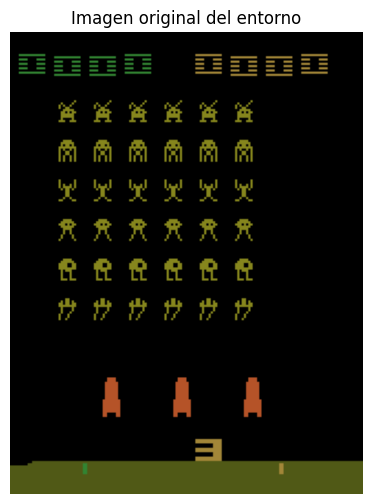

In [ ]:
# ============================
# 6. Mostrar imagen original del entorno
# ============================

def reset_env_compat(env):
    result = env.reset()
    if isinstance(result, tuple):
        return result[0]
    return result

raw_env = gym.make(ENV_ID)
obs = reset_env_compat(raw_env)

try:
    frame_rgb = raw_env.render(mode='rgb_array')
except TypeError:
    frame_rgb = raw_env.render()

plt.figure(figsize=(6, 6))
plt.imshow(frame_rgb)
plt.title('Imagen original del entorno')
plt.axis('off')
plt.show()

raw_env.close()


In [ ]:
# ============================
# 7. Crear entorno vectorizado para SB3
# ============================
# make_atari_env aplica los wrappers habituales de Atari.
# clip_reward=True hace que la recompensa sea clipped [-1, 0, 1].
# VecFrameStack apila 4 imágenes consecutivas.

def create_env():
    env = make_atari_env(
        ENV_ID,
        n_envs=1,
        seed=SEED,
        monitor_dir=str(OUTPUT_DIR / 'monitor'),
        wrapper_kwargs=dict(clip_reward=True)
    )
    env = VecFrameStack(env, n_stack=4)
    return env

env = create_env()
print('Observation space SB3:', env.observation_space)
print('Action space SB3:', env.action_space)

Observation space SB3: Box(0, 255, (84, 84, 4), uint8)
Action space SB3: Discrete(6)


Shape observación: (1, 84, 84, 4)


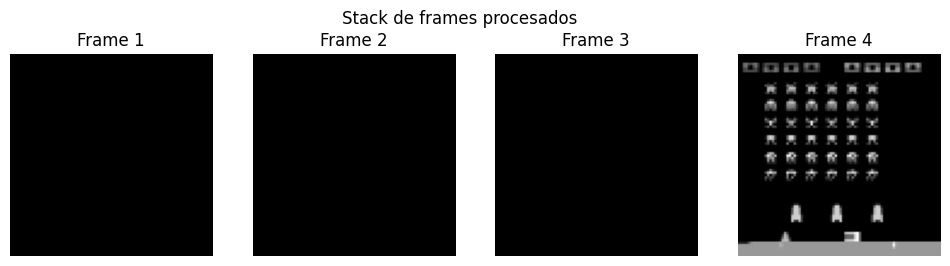

In [ ]:
# ============================
# 8. Mostrar imágenes procesadas 84x84 y stack de frames
# ============================

obs = env.reset()
print('Shape observación:', obs.shape)

# Normalmente con CnnPolicy/SB3 queda en formato: (n_envs, channels, height, width)
obs0 = obs[0]

if obs0.shape[0] in [1, 3, 4, 12]:
    # channels first
    frames = obs0
else:
    # channels last
    frames = np.transpose(obs0, (2, 0, 1))

num_frames = min(4, frames.shape[0])

plt.figure(figsize=(12, 3))
for i in range(num_frames):
    plt.subplot(1, num_frames, i + 1)
    plt.imshow(frames[i], cmap='gray')
    plt.title(f'Frame {i + 1}')
    plt.axis('off')
plt.suptitle('Stack de frames procesados')
plt.show()


In [ ]:
# ============================
# 9. Red convolucional personalizada 84x84
# ============================
# Arquitectura tipo DQN Atari:
# Entrada: 4 x 84 x 84
# Conv2D 32 filtros 8x8 stride 4
# Conv2D 64 filtros 4x4 stride 2
# Conv2D 64 filtros 3x3 stride 1
# Capa densa de 512 características

class CustomCNN84(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=512):
        super().__init__(observation_space, features_dim)

        n_input_channels = observation_space.shape[0]

        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten()
        )

        with th.no_grad():
            sample = th.as_tensor(observation_space.sample()[None]).float()
            n_flatten = self.cnn(sample).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        return self.linear(self.cnn(observations))

policy_kwargs = dict(
    features_extractor_class=CustomCNN84,
    features_extractor_kwargs=dict(features_dim=512),
    net_arch=[]
)


In [ ]:
# ============================
# 9. Función auxiliar de guardado
# ============================
# Esta función solo se usa como alternativa si model.save(...) falla por problemas
# de serialización en Colab/Python. El logger oficial será el de SB3/TensorBoard.

def save_policy_checkpoint(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    th.save(
        {
            "policy_state_dict": model.policy.state_dict(),
            "optimizer_state_dict": model.policy.optimizer.state_dict(),
            "num_timesteps": model.num_timesteps,
            "exploration_rate": getattr(model, "exploration_rate", None),
        },
        path
    )


In [ ]:
# ============================
# 10. Logger completo y callback personalizado
# ============================
# Guarda todas las métricas propias en JSON y CSV.
# Además registra métricas custom en TensorBoard/SB3.

class SB3TrainingLogger:
    def __init__(self, json_path, csv_path):
        self.json_path = Path(json_path)
        self.csv_path = Path(csv_path)
        self.json_path.parent.mkdir(parents=True, exist_ok=True)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)

        if self.json_path.exists():
            with open(self.json_path, 'r') as f:
                self.data = json.load(f)
            print('Log JSON previo cargado:', self.json_path)
        else:
            self.data = {
                'episode': [],
                'total_steps': [],
                'episode_reward': [],
                'clipped_episode_reward': [],
                'consecutive_clipped_over_20': [],
                'max_consecutive_clipped_over_20': [],
                'avg_clip50': [],
                'duration': [],
                'exploration_rate': []
            }

    def add_episode(self, episode, total_steps, reward, clipped_reward,
                    consecutive, max_consecutive, avg_clip50, duration,
                    exploration_rate):
        row = {
            'episode': int(episode),
            'total_steps': int(total_steps),
            'episode_reward': float(reward),
            'clipped_episode_reward': float(clipped_reward),
            'consecutive_clipped_over_20': int(consecutive),
            'max_consecutive_clipped_over_20': int(max_consecutive),
            'avg_clip50': float(avg_clip50),
            'duration': float(duration),
            'exploration_rate': float(exploration_rate) if exploration_rate is not None else np.nan
        }

        for key, value in row.items():
            self.data[key].append(value)

        # CSV incremental: se guarda en cada episodio para no perder información si Colab se corta.
        pd.DataFrame([row]).to_csv(
            self.csv_path,
            mode='a',
            header=not self.csv_path.exists(),
            index=False
        )

    def save_json(self):
        with open(self.json_path, 'w') as f:
            json.dump(self.data, f, indent=2)

    def __len__(self):
        return len(self.data.get('episode', []))


class ConsecutiveRewardCallback(BaseCallback):
    def __init__(self, training_logger, verbose=0):
        super().__init__(verbose)
        self.training_logger = training_logger
        self.episode = len(training_logger)
        self.consecutive = 0
        self.max_consecutive = 0
        self.recent_clipped_rewards = deque(maxlen=50)
        self.start_time = time.time()
        self.last_json_save_step = 0

        previous_clipped = training_logger.data.get('clipped_episode_reward', [])[-50:]
        for value in previous_clipped:
            self.recent_clipped_rewards.append(float(value))

        previous_consec = training_logger.data.get('consecutive_clipped_over_20', [])
        if len(previous_consec) > 0:
            self.consecutive = int(previous_consec[-1])

        previous_max = training_logger.data.get('max_consecutive_clipped_over_20', [])
        if len(previous_max) > 0:
            self.max_consecutive = int(max(previous_max))

    def _on_step(self) -> bool:
        infos = self.locals.get('infos', [])

        for info in infos:
            if 'episode' not in info:
                continue

            ep_reward = float(info['episode']['r'])

            # Métrica comparable con tu práctica anterior.
            # En esta configuración SB3 informa reward real; para Space Invaders se usa /10.
            clipped_reward = ep_reward / 10.0

            duration = time.time() - self.start_time
            self.start_time = time.time()

            self.recent_clipped_rewards.append(clipped_reward)

            if clipped_reward > CONSECUTIVE_THRESHOLD:
                self.consecutive += 1
            else:
                self.consecutive = 0

            if self.consecutive > self.max_consecutive:
                self.max_consecutive = self.consecutive

            avg_clip50 = (
                float(np.mean(self.recent_clipped_rewards))
                if len(self.recent_clipped_rewards) > 0
                else 0.0
            )

            exploration_rate = getattr(self.model, 'exploration_rate', np.nan)

            self.training_logger.add_episode(
                episode=self.episode,
                total_steps=self.num_timesteps,
                reward=ep_reward,
                clipped_reward=clipped_reward,
                consecutive=self.consecutive,
                max_consecutive=self.max_consecutive,
                avg_clip50=avg_clip50,
                duration=duration,
                exploration_rate=exploration_rate
            )

            # Métricas personalizadas para TensorBoard/SB3.
            self.logger.record('custom/clipped_episode_reward', clipped_reward)
            self.logger.record('custom/consecutive_clipped_over_20', self.consecutive)
            self.logger.record('custom/max_consecutive_clipped_over_20', self.max_consecutive)
            self.logger.record('custom/avg_clip50', avg_clip50)

            if self.episode % PRINT_EVERY_EPISODES == 0:
                print(
                    f'EP={self.episode:,} | '
                    f'STEP={self.num_timesteps:,} | '
                    f'clip={clipped_reward:.0f} | '
                    f'consec={self.consecutive} | '
                    f'max_consec={self.max_consecutive} | '
                    f'avg_clip50={avg_clip50:.2f}'
                )

            self.episode += 1

            if self.max_consecutive >= TARGET_CONSECUTIVE_EPISODES:
                print('Objetivo conseguido: 100 episodios consecutivos superando el umbral.')
                self.training_logger.save_json()
                return False

        if self.num_timesteps - self.last_json_save_step >= SAVE_FREQ_STEPS:
            self.training_logger.save_json()
            self.last_json_save_step = self.num_timesteps

        return True

    def _on_training_end(self):
        self.training_logger.save_json()
        print('Entrenamiento finalizado.')
        print('max_consec alcanzado:', self.max_consecutive)
        print('Log JSON:', LOG_FILENAME)
        print('Log CSV:', CSV_LOG_FILENAME)


In [ ]:
# ============================
# 11. Crear o cargar modelo DQN
# ============================

if LOAD_MODEL and MODEL_LATEST.exists():
    print("Cargando modelo desde:", MODEL_LATEST)

    model = DQN.load(
        str(MODEL_LATEST),
        env=env,
        device="auto",
        tensorboard_log=str(TENSORBOARD_DIR)
    )

    print("Modelo cargado correctamente.")

else:
    print("Creando modelo nuevo.")

    model = DQN(
        policy="CnnPolicy",
        env=env,
        learning_rate=LEARNING_RATE,
        buffer_size=BUFFER_SIZE,
        learning_starts=LEARNING_STARTS,
        batch_size=BATCH_SIZE,
        gamma=GAMMA,
        train_freq=TRAIN_FREQ,
        target_update_interval=TARGET_UPDATE_INTERVAL,
        exploration_initial_eps=EXPLORATION_INITIAL_EPS,
        exploration_final_eps=EXPLORATION_FINAL_EPS,
        exploration_fraction=EXPLORATION_FRACTION,
        policy_kwargs=policy_kwargs,
        tensorboard_log=str(TENSORBOARD_DIR),
        verbose=1,
        seed=SEED,
        device="auto"
    )

    print("Modelo nuevo creado correctamente.")

print("Política usada:")
print(model.policy)


Creando modelo nuevo.
Using cuda device
Wrapping the env in a VecTransposeImage.
Modelo nuevo creado correctamente.
Política usada:
CnnPolicy(
  (q_net): QNetwork(
    (features_extractor): CustomCNN84(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
        (3): ReLU()
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
        (5): ReLU()
        (6): Flatten(start_dim=1, end_dim=-1)
      )
      (linear): Sequential(
        (0): Linear(in_features=3136, out_features=512, bias=True)
        (1): ReLU()
      )
    )
    (q_net): Sequential(
      (0): Linear(in_features=512, out_features=6, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): CustomCNN84(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
       

In [ ]:
# ============================
# 12. Entrenamiento
# ============================

training_logger = SB3TrainingLogger(
    json_path=LOG_FILENAME,
    csv_path=CSV_LOG_FILENAME
)

callback = ConsecutiveRewardCallback(
    training_logger=training_logger,
    verbose=1
)

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback,
    reset_num_timesteps=not LOAD_MODEL,
    tb_log_name='DQN_SpaceInvaders_v0',
    log_interval=100
)


Se han truncado las últimas 5000 líneas del flujo de salida.
EP=4,590 | STEP=802,238 | clip=22 | consec=3 | max_consec=8 | avg_clip50=22.83
--------------------------------------
| custom/                 |          |
|    avg_clip50           | 22.8     |
|    clipped_episode_r... | 16.5     |
|    consecutive_clipp... | 0        |
|    max_consecutive_c... | 8        |
| rollout/                |          |
|    ep_len_mean          | 838      |
|    ep_rew_mean          | 225      |
|    exploration rate     | 0.732    |
| time/                   |          |
|    episodes             | 13700    |
|    fps                  | 262      |
|    time_elapsed         | 3057     |
|    total timesteps      | 803356   |
| train/                  |          |
|    learning_rate        | 0.0001   |
|    loss                 | 0.0988   |
|    n_updates            | 188338   |
--------------------------------------
EP=4,600 | STEP=804,242 | clip=3 | consec=0 | max_consec=8 | avg_clip50=21.31
EP

In [ ]:
# ============================
# 13. Guardado manual del modelo
# ============================
# Primero se intenta guardar con SB3. Si falla por serialización ,
# se guarda únicamente la política y el optimizador con PyTorch.

try:
    model.save(str(MODEL_LATEST))
    print('Modelo completo SB3 guardado en:', MODEL_LATEST)

except Exception as e:
    print('No se pudo guardar el modelo completo con SB3.')
    print('Error:', repr(e))
    save_policy_checkpoint(model, POLICY_LATEST)
    print('Política/optimizador guardados con PyTorch en:', POLICY_LATEST)


No se pudo guardar el modelo completo con SB3.
Error: IndexError('tuple index out of range')
Política/optimizador guardados con PyTorch en: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_policy_latest.pt


Filas registradas: 11961
Columnas: ['episode', 'total_steps', 'episode_reward', 'clipped_episode_reward', 'consecutive_clipped_over_20', 'max_consecutive_clipped_over_20', 'avg_clip50', 'duration', 'exploration_rate']


,episode,total_steps,episode_reward,clipped_episode_reward,consecutive_clipped_over_20,max_consecutive_clipped_over_20,avg_clip50,duration,exploration_rate
11951,11921,2630487,525.0,52.5,91,91,60.98,1.602062,0.124048
11952,11922,2630696,595.0,59.5,92,92,61.03,0.948333,0.123979
11953,11923,2631025,520.0,52.0,93,93,60.92,1.414632,0.123869
11954,11924,2631553,1300.0,130.0,94,94,62.58,2.251499,0.123693
11955,11925,2631852,530.0,53.0,95,95,62.64,1.295319,0.123594
11956,11926,2632170,550.0,55.0,96,96,62.54,1.395159,0.123488
11957,11927,2632426,500.0,50.0,97,97,61.22,1.144407,0.123402
11958,11928,2632752,575.0,57.5,98,98,59.75,1.415885,0.123294
11959,11929,2632938,435.0,43.5,99,99,59.42,0.851201,0.123232
11960,11930,2633424,975.0,97.5,100,100,60.29,2.080515,0.123070


,metrica,valor
0,episodios_registrados,1.196100e+04
1,ultimo_step,2.633424e+06
2,mejor_clip,1.580000e+02
3,mejor_avg_clip50,6.361000e+01
4,mejor_max_consec,1.000000e+02
5,ultimo_avg_clip50,6.029000e+01
6,ultimo_exploration_rate,1.230701e-01


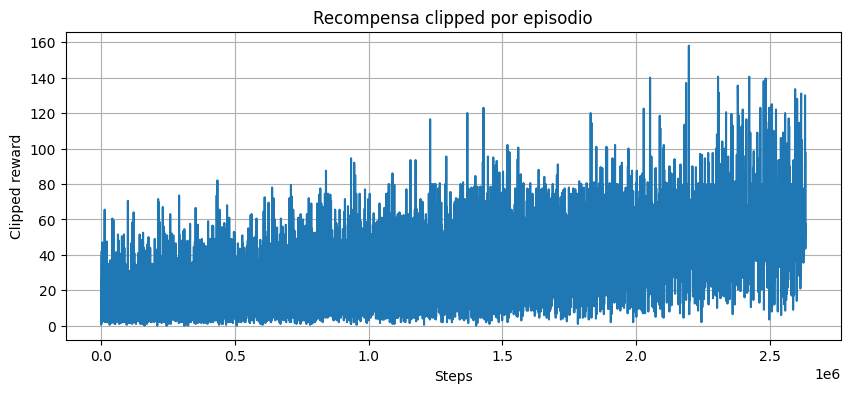

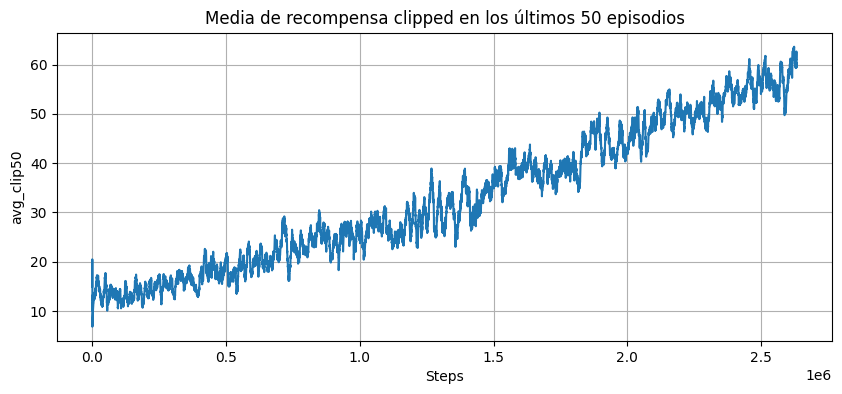

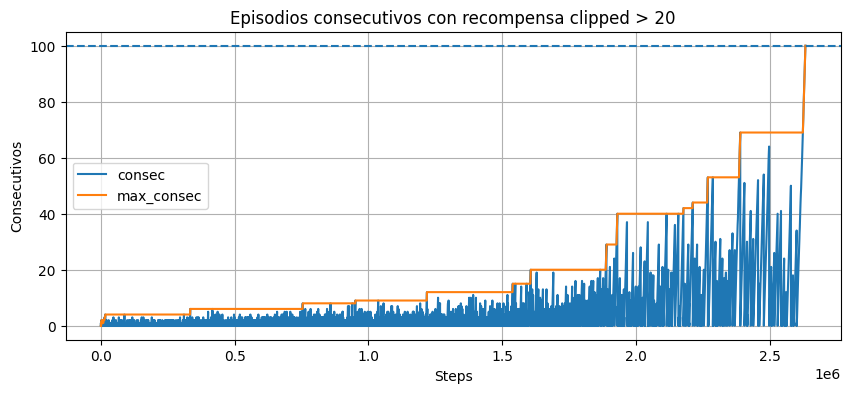

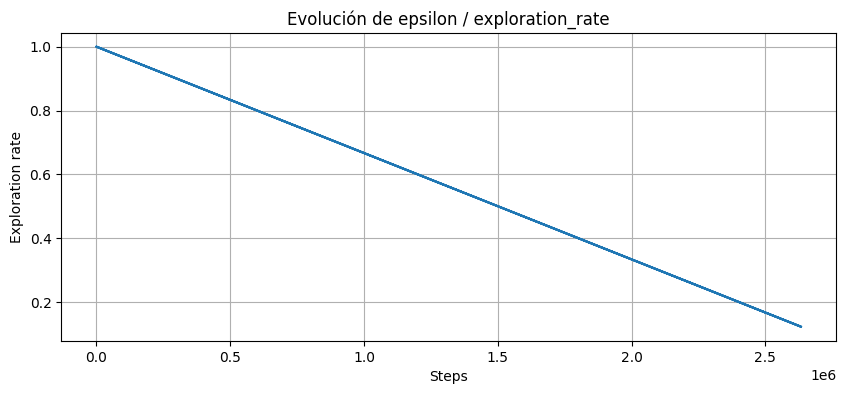

Mejor max_consec: 100
Mejor avg_clip50: 63.61


In [ ]:
# ============================
# 14. Tablas y gráficas del entrenamiento
# ============================

if not CSV_LOG_FILENAME.exists():
    raise FileNotFoundError(f'No existe el log CSV: {CSV_LOG_FILENAME}')

df = pd.read_csv(CSV_LOG_FILENAME)
print('Filas registradas:', len(df))
print('Columnas:', list(df.columns))

display(df.tail(10))

summary_table = pd.DataFrame({
    'metrica': [
        'episodios_registrados',
        'ultimo_step',
        'mejor_clip',
        'mejor_avg_clip50',
        'mejor_max_consec',
        'ultimo_avg_clip50',
        'ultimo_exploration_rate'
    ],
    'valor': [
        len(df),
        int(df['total_steps'].iloc[-1]) if len(df) else 0,
        float(df['clipped_episode_reward'].max()) if len(df) else 0.0,
        float(df['avg_clip50'].max()) if len(df) else 0.0,
        int(df['max_consecutive_clipped_over_20'].max()) if len(df) else 0,
        float(df['avg_clip50'].iloc[-1]) if len(df) else 0.0,
        float(df['exploration_rate'].iloc[-1]) if 'exploration_rate' in df and len(df) else np.nan
    ]
})

display(summary_table)

steps = df['total_steps'].to_numpy()
clipped = df['clipped_episode_reward'].to_numpy()
consec = df['consecutive_clipped_over_20'].to_numpy()
max_consec = df['max_consecutive_clipped_over_20'].to_numpy()
avg50 = df['avg_clip50'].to_numpy()

plt.figure(figsize=(10, 4))
plt.plot(steps, clipped)
plt.title('Recompensa clipped por episodio')
plt.xlabel('Steps')
plt.ylabel('Clipped reward')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(steps, avg50)
plt.title('Media de recompensa clipped en los últimos 50 episodios')
plt.xlabel('Steps')
plt.ylabel('avg_clip50')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(steps, consec, label='consec')
plt.plot(steps, max_consec, label='max_consec')
plt.axhline(TARGET_CONSECUTIVE_EPISODES, linestyle='--')
plt.title('Episodios consecutivos con recompensa clipped > 20')
plt.xlabel('Steps')
plt.ylabel('Consecutivos')
plt.legend()
plt.grid(True)
plt.show()

if 'exploration_rate' in df.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(steps, df['exploration_rate'])
    plt.title('Evolución de epsilon / exploration_rate')
    plt.xlabel('Steps')
    plt.ylabel('Exploration rate')
    plt.grid(True)
    plt.show()

print('Mejor max_consec:', int(max(max_consec)) if len(max_consec) else 0)
print('Mejor avg_clip50:', float(max(avg50)) if len(avg50) else 0.0)


No se pudo cargar MODEL_LATEST. Se usa el modelo actual en memoria.
Error: ValueError("Error: the file <_io.BufferedReader name='/content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_sb3_latest.zip'> wasn't a zip-file")


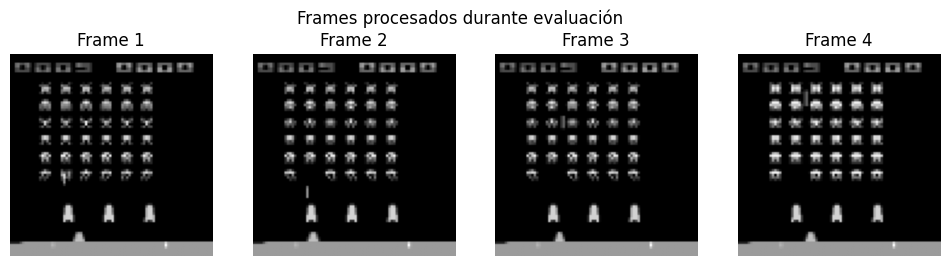

In [ ]:
# ============================
# 15. Evaluación visual rápida
# ============================
# Si existe el modelo completo de SB3, se carga.
# Si no, se usa el modelo actual de memoria.

if MODEL_LATEST.exists():
    try:
        model = DQN.load(str(MODEL_LATEST), env=env, device='auto')
        print('Modelo cargado para evaluación:', MODEL_LATEST)
    except Exception as e:
        print('No se pudo cargar MODEL_LATEST. Se usa el modelo actual en memoria.')
        print('Error:', repr(e))
else:
    print('No existe MODEL_LATEST. Se usa el modelo actual en memoria.')

obs = env.reset()
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

obs0 = obs[0]
if obs0.shape[0] in [1, 3, 4, 12]:
    frames = obs0
else:
    frames = np.transpose(obs0, (2, 0, 1))

num_frames = min(4, frames.shape[0])
plt.figure(figsize=(12, 3))
for i in range(num_frames):
    plt.subplot(1, num_frames, i + 1)
    plt.imshow(frames[i], cmap='gray')
    plt.title(f'Frame {i + 1}')
    plt.axis('off')
plt.suptitle('Frames procesados durante evaluación')
plt.show()


In [ ]:
# ============================
# 16. Cerrar entorno
# ============================

# env.close()


In [ ]:
# ============================
# 17. Comprobación final de ficheros y resultados
# ============================

print('OUTPUT_DIR:', OUTPUT_DIR)
print('Existe OUTPUT_DIR:', OUTPUT_DIR.exists())
print('MODEL_LATEST:', MODEL_LATEST, '| existe:', MODEL_LATEST.exists())
print('POLICY_LATEST:', POLICY_LATEST, '| existe:', POLICY_LATEST.exists())
print('LOG_FILENAME:', LOG_FILENAME, '| existe:', LOG_FILENAME.exists())
print('CSV_LOG_FILENAME:', CSV_LOG_FILENAME, '| existe:', CSV_LOG_FILENAME.exists())
print('TENSORBOARD_DIR:', TENSORBOARD_DIR, '| existe:', TENSORBOARD_DIR.exists())
print('MONITOR_DIR:', MONITOR_DIR, '| existe:', MONITOR_DIR.exists())

if CSV_LOG_FILENAME.exists():
    df_check = pd.read_csv(CSV_LOG_FILENAME)
    print('\nResumen del log CSV')
    print('Episodios registrados:', len(df_check))

    if len(df_check) > 0:
        print('Último episodio:', int(df_check['episode'].iloc[-1]))
        print('Último step:', int(df_check['total_steps'].iloc[-1]))
        print('Mejor clipped_episode_reward:', float(df_check['clipped_episode_reward'].max()))
        print('Mejor avg_clip50:', float(df_check['avg_clip50'].max()))
        print('Mejor max_consec:', int(df_check['max_consecutive_clipped_over_20'].max()))
        print('Último avg_clip50:', float(df_check['avg_clip50'].iloc[-1]))

        display(df_check.tail(5))
else:
    print('\nNo se encontró el CSV de entrenamiento. Ejecuta el bloque de entrenamiento con el callback actualizado.')

if LOG_FILENAME.exists():
    with open(LOG_FILENAME, 'r') as f:
        data_check = json.load(f)
    print('\nResumen del log JSON')
    print('Claves:', list(data_check.keys()))
    print('Episodios en JSON:', len(data_check.get('episode', [])))
else:
    print('\nNo se encontró el JSON de entrenamiento.')

# Listado breve de ficheros creados en la carpeta del proyecto.
print('\nFicheros principales en OUTPUT_DIR:')
for p in sorted(OUTPUT_DIR.glob('*')):
    if p.is_file():
        print(f'- {p.name} ({p.stat().st_size / 1024:.1f} KB)')
    else:
        print(f'- {p.name}/')


OUTPUT_DIR: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0
Existe OUTPUT_DIR: True
MODEL_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_sb3_latest.zip | existe: True
POLICY_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_policy_latest.pt | existe: True
LOG_FILENAME: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_SpaceInvaders-v0_sb3_log.json | existe: True
CSV_LOG_FILENAME: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_SpaceInvaders-v0_sb3_log.csv | existe: True
TENSORBOARD_DIR: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/tensorboard | existe: True
MONITOR_DIR: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/monitor | existe: True

Resumen del log CSV
Episodios registrados: 11961
Último episodio: 11930
Último step: 2633424
Mejor clip

,episode,total_steps,episode_reward,clipped_episode_reward,consecutive_clipped_over_20,max_consecutive_clipped_over_20,avg_clip50,duration,exploration_rate
11956,11926,2632170,550.0,55.0,96,96,62.54,1.395159,0.123488
11957,11927,2632426,500.0,50.0,97,97,61.22,1.144407,0.123402
11958,11928,2632752,575.0,57.5,98,98,59.75,1.415885,0.123294
11959,11929,2632938,435.0,43.5,99,99,59.42,0.851201,0.123232
11960,11930,2633424,975.0,97.5,100,100,60.29,2.080515,0.123070



Resumen del log JSON
Claves: ['episode', 'total_steps', 'episode_reward', 'clipped_episode_reward', 'consecutive_clipped_over_20', 'max_consecutive_clipped_over_20', 'avg_clip50', 'duration', 'exploration_rate']
Episodios en JSON: 11931

Ficheros principales en OUTPUT_DIR:
- .DS_Store (6.0 KB)
- dqn_SpaceInvaders-v0_sb3_log.csv (819.1 KB)
- dqn_SpaceInvaders-v0_sb3_log.json (1341.4 KB)
- dqn_spaceinvaders_v0_policy_latest.pt (26381.2 KB)
- dqn_spaceinvaders_v0_sb3_latest.zip (0.0 KB)
- monitor/
- tensorboard/


In [ ]:
# ============================
# Entorno de evaluación real
# ============================

import gym
import numpy as np
from stable_baselines3.common.atari_wrappers import (
    MaxAndSkipEnv,
    FireResetEnv,
    WarpFrame
)
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack, VecTransposeImage

def create_eval_env():
    def make_env():
        env = gym.make(ENV_ID)

        env.seed(SEED)
        env = MaxAndSkipEnv(env, skip=4)

        if "FIRE" in env.unwrapped.get_action_meanings():
            env = FireResetEnv(env)

        env = WarpFrame(env)

        return env

    env = DummyVecEnv([make_env])
    env = VecFrameStack(env, n_stack=4)
    env = VecTransposeImage(env)

    return env

In [ ]:
# ============================
# Cargar policy aprendida
# ============================

import torch
from stable_baselines3 import DQN

POLICY_LATEST = OUTPUT_DIR / "dqn_spaceinvaders_v0_policy_latest.pt"

eval_env = create_eval_env()

model = DQN(
    policy="CnnPolicy",
    env=eval_env,
    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    gamma=GAMMA,
    train_freq=TRAIN_FREQ,
    target_update_interval=TARGET_UPDATE_INTERVAL,
    exploration_initial_eps=EXPLORATION_INITIAL_EPS,
    exploration_final_eps=EXPLORATION_FINAL_EPS,
    exploration_fraction=EXPLORATION_FRACTION,
    policy_kwargs=policy_kwargs,
    verbose=1,
    seed=SEED,
    device="auto"
)

checkpoint = torch.load(POLICY_LATEST, map_location=model.device)

model.policy.load_state_dict(checkpoint["policy_state_dict"])
model.num_timesteps = checkpoint["num_timesteps"]
model.exploration_rate = checkpoint["exploration_rate"]

print("Policy cargada correctamente")
print("Timesteps:", model.num_timesteps)
print("Exploration rate:", model.exploration_rate)

Using cuda device
Policy cargada correctamente
Timesteps: 2633424
Exploration rate: 0.12307014100000035


In [ ]:
# ============================
# Testing sin entrenamiento
# ============================

TEST_EPISODES = 120

rewards = []
clipped_rewards = []

for ep in range(TEST_EPISODES):
    obs = eval_env.reset()
    done = False
    total_reward = 0.0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, infos = eval_env.step(action)
        total_reward += float(reward[0])
        done = bool(done[0])

    clipped_reward = total_reward / 10.0
    rewards.append(total_reward)
    clipped_rewards.append(clipped_reward)

    print(
        f"TEST EP={ep+1:03d} | "
        f"reward={total_reward:.0f} | "
        f"clip={clipped_reward:.0f}"
    )

print("Reward medio:", np.mean(rewards))
print("Clip medio:", np.mean(clipped_rewards))
print("Reward máximo:", np.max(rewards))
print("Clip máximo:", np.max(clipped_rewards))

eval_env.close()

TEST EP=001 | reward=900 | clip=90
TEST EP=002 | reward=600 | clip=60
TEST EP=003 | reward=575 | clip=58
TEST EP=004 | reward=570 | clip=57
TEST EP=005 | reward=800 | clip=80
TEST EP=006 | reward=600 | clip=60
TEST EP=007 | reward=545 | clip=54
TEST EP=008 | reward=555 | clip=56
TEST EP=009 | reward=360 | clip=36
TEST EP=010 | reward=575 | clip=58
TEST EP=011 | reward=1180 | clip=118
TEST EP=012 | reward=600 | clip=60
TEST EP=013 | reward=575 | clip=58
TEST EP=014 | reward=545 | clip=54
TEST EP=015 | reward=600 | clip=60
TEST EP=016 | reward=915 | clip=92
TEST EP=017 | reward=800 | clip=80
TEST EP=018 | reward=575 | clip=58
TEST EP=019 | reward=600 | clip=60
TEST EP=020 | reward=605 | clip=60
TEST EP=021 | reward=775 | clip=78
TEST EP=022 | reward=575 | clip=58
TEST EP=023 | reward=1295 | clip=130
TEST EP=024 | reward=600 | clip=60
TEST EP=025 | reward=425 | clip=42
TEST EP=026 | reward=1000 | clip=100
TEST EP=027 | reward=605 | clip=60
TEST EP=028 | reward=600 | clip=60
TEST EP=029 | 

## Vídeo del juego

Se graban dos vídeos con la política **del modelo base ya entrenado** (determinista, cargada previamente desde su checkpoint con la celda "Cargar policy aprendida"). Esto sustituye a la renderización en vivo de gym, que no es compatible con Colab:

1. **Una partida individual** (el wrapper de Atari corta el episodio al perder una vida).
2. **10 episodios seguidos** en un único mp4, para observar el comportamiento del agente de forma más representativa.

Los vídeos quedan embebidos en el notebook. Las variantes de la Parte 2 se comparan de forma **cuantitativa** mediante las gráficas y el test de 120 episodios, por lo que no aporta información adicional grabar una partida por cada variante.


In [ ]:
# ============================
# Grabar una partida en vídeo
# ============================

from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder
from IPython.display import display
import shutil

VIDEO_DIR = OUTPUT_DIR / 'video_1'
if VIDEO_DIR.exists():
    shutil.rmtree(VIDEO_DIR)
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

video_env = make_atari_env(
    ENV_ID,
    n_envs=1,
    seed=SEED,
    wrapper_kwargs=dict(clip_reward=True)
 )
video_env = VecFrameStack(video_env, n_stack=4)
video_env = VecVideoRecorder(
    video_env,
    str(VIDEO_DIR),
    record_video_trigger=lambda step: step == 0,
    video_length=5_000,
    name_prefix='sb3-spaceinvaders'
 )

obs = video_env.reset()
for _ in range(5_000):
    action, _ = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = video_env.step(action)
    if bool(dones[0]):
        break

video_env.close()

video_files = sorted(VIDEO_DIR.glob('*.mp4'))
print('Vídeos generados:', [video_file.name for video_file in video_files])
display(video_files[0] if video_files else 'No se ha generado ningún vídeo.')

Vídeos generados: ['sb3-spaceinvaders-step-0-to-step-5000.mp4']


PosixPath('/content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo/datos/sb3_1_spaceinvaders_v0/video_1/sb3-spaceinvaders-step-0-to-step-5000.mp4')

In [ ]:
# Reproducir el MP4 generado dentro del notebook
import io
import base64
from IPython.display import HTML

video_files = sorted(VIDEO_DIR.glob('*.mp4'))
if not video_files:
    raise FileNotFoundError(f'No se encontró ningún MP4 en {VIDEO_DIR}')

video_path = video_files[0]
with io.open(video_path, 'r+b') as video_file:
    video = video_file.read()

encoded = base64.b64encode(video).decode('ascii')
HTML(
    data=f'''
    <video width="640" height="auto" alt="space-invaders" controls>
        <source src="data:video/mp4;base64,{encoded}" type="video/mp4" />
    </video>'''
)

In [ ]:
# ============================
# Grabar 10 partidas en un único mp4
# ============================

from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder
import shutil

N_EPISODES = 10
MAX_STEPS_PER_EP = 5_000  # margen por episodio, ajusta si Space Invaders dura menos

VIDEO_DIR = OUTPUT_DIR / 'video_10'
if VIDEO_DIR.exists():
    shutil.rmtree(VIDEO_DIR)
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

video_env = make_atari_env(
    ENV_ID,
    n_envs=1,
    seed=SEED,
    wrapper_kwargs=dict(clip_reward=False)
)
video_env = VecFrameStack(video_env, n_stack=4)
video_env = VecVideoRecorder(
    video_env,
    str(VIDEO_DIR),
    record_video_trigger=lambda step: step == 0,
    video_length=N_EPISODES * MAX_STEPS_PER_EP,  # cubre las 10 partidas seguidas
    name_prefix='sb3-spaceinvaders-10eps'
)

obs = video_env.reset()
episodes_done = 0
step = 0
while episodes_done < N_EPISODES:
    action, _ = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = video_env.step(action)
    step += 1
    if bool(dones[0]):
        episodes_done += 1  # el VecEnv ya resetea internamente, obs ya es del nuevo episodio

video_env.close()


In [ ]:
# Reproducir el MP4 generado dentro del notebook
import io
import base64
from IPython.display import HTML

video_files = sorted(VIDEO_DIR.glob('*.mp4'))
if not video_files:
    raise FileNotFoundError(f'No se encontró ningún MP4 en {VIDEO_DIR}')

video_path = video_files[0]
with io.open(video_path, 'r+b') as video_file:
    video = video_file.read()

encoded = base64.b64encode(video).decode('ascii')
HTML(
    data=f'''
    <video width="640" height="auto" alt="space-invaders" controls>
        <source src="data:video/mp4;base64,{encoded}" type="video/mp4" />
    </video>'''
)

---
# PARTE 2 (ampliación). Propuestas de mejora sobre el DQN base

El DQN entrenado en las secciones anteriores actúa como **referencia (baseline)**. Sobre él se implementan y comparan **tres propuestas de mejora** independientes. No se combinan entre sí a propósito: así se puede aislar y discutir el efecto de cada una.

| # | Propuesta | Qué cambia | Motivación |
|---|-----------|------------|------------|
| 1 | **Double DQN** (van Hasselt et al., 2016) | El target pasa de `max_a Q_target(s',a)` a `Q_target(s', argmax_a Q_online(s',a))` | El operador `max` sobre estimaciones ruidosas sobreestima sistemáticamente los valores Q; separar la *selección* de la acción (red online) de su *evaluación* (red target) reduce ese sesgo |
| 2 | **Dueling DQN** (Wang et al., 2016) | La cabeza de la red se divide en dos streams: `V(s)` y `A(s,a)`, con `Q = V + A - mean(A)` | En muchos estados de Space Invaders la acción elegida apenas cambia el valor del estado (p. ej. cuando no hay proyectiles cerca); estimar `V(s)` por separado propaga aprendizaje a todas las acciones a la vez |
| 3 | **Exploración ajustada** | `exploration_fraction` 0.30 → 0.10, `ε_final` 0.001 → 0.01, `target_update_interval` 10k → 5k, `learning_starts` 50k → 25k | El run base terminó con ε ≈ 0.12: el 12 % de las acciones seguían siendo aleatorias incluso al final del entrenamiento. Un annealing más corto, adaptado al presupuesto real, permite explotar antes lo aprendido |

**Protocolo de comparación justa:** misma semilla (42), mismo preprocesado y misma red convolucional base, mismo presupuesto máximo de steps, mismo criterio de parada (100 episodios consecutivos con recompensa clipped > 20) y mismo test final (120 episodios con política determinista).


In [ ]:
# ============================
# M1. Infraestructura multi-run: rutas por variante y helpers
# ============================
# Cada variante escribe sus logs y checkpoints en su propia carpeta de Drive,
# reutilizando SB3TrainingLogger y ConsecutiveRewardCallback sin cambios.
# La variante 'base' apunta a la carpeta del entrenamiento ya realizado.

RUN_NAMES = ['base', 'double', 'dueling', 'tuned']

RUN_LABELS = {
    'base': 'DQN base',
    'double': 'Double DQN',
    'dueling': 'Dueling DQN',
    'tuned': 'DQN exploración ajustada',
}

def setup_run_paths(run_name):
    if run_name == 'base':
        run_dir = OUTPUT_DIR
    else:
        run_dir = Path(drive_root) / 'datos' / (PROJECT_NAME + '_' + run_name)
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / 'monitor').mkdir(parents=True, exist_ok=True)
    (run_dir / 'tensorboard').mkdir(parents=True, exist_ok=True)
    return {
        'dir': run_dir,
        'policy': run_dir / 'dqn_spaceinvaders_v0_policy_latest.pt',
        'model_zip': run_dir / 'dqn_spaceinvaders_v0_sb3_latest.zip',
        'json': run_dir / 'dqn_SpaceInvaders-v0_sb3_log.json',
        'csv': run_dir / 'dqn_SpaceInvaders-v0_sb3_log.csv',
        'monitor': run_dir / 'monitor',
        'tensorboard': run_dir / 'tensorboard',
        'test_json': run_dir / 'test_results.json',
    }

RUN_PATHS = {name: setup_run_paths(name) for name in RUN_NAMES}

def create_train_env(monitor_dir):
    env = make_atari_env(
        ENV_ID,
        n_envs=1,
        seed=SEED,
        monitor_dir=str(monitor_dir),
        wrapper_kwargs=dict(clip_reward=True)
    )
    return VecFrameStack(env, n_stack=4)

def train_variant(run_name, model, total_timesteps=TOTAL_TIMESTEPS):
    paths = RUN_PATHS[run_name]
    training_logger = SB3TrainingLogger(json_path=paths['json'], csv_path=paths['csv'])
    callback = ConsecutiveRewardCallback(training_logger=training_logger, verbose=1)

    model.learn(
        total_timesteps=total_timesteps,
        callback=callback,
        reset_num_timesteps=True,
        tb_log_name='DQN_' + run_name,
        log_interval=100
    )

    # Siempre se guarda el checkpoint PyTorch (el formato que sabemos cargar);
    # el .zip de SB3 se intenta como extra (en el run base fallaba en Colab).
    save_policy_checkpoint(model, paths['policy'])
    print('Checkpoint PyTorch guardado en:', paths['policy'])
    try:
        model.save(str(paths['model_zip']))
        print('Modelo SB3 guardado en:', paths['model_zip'])
    except Exception as e:
        print('model.save() falló (no es crítico, se usa el .pt):', repr(e))

    return model

print('Rutas por variante creadas:')
for name in RUN_NAMES:
    print(' -', RUN_LABELS[name], '->', RUN_PATHS[name]['dir'])


Rutas por variante creadas:
 - DQN base -> /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0
 - Double DQN -> /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0_double
 - Dueling DQN -> /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0_dueling
 - DQN exploración ajustada -> /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0_tuned


In [ ]:
# ============================
# M2. Propuesta 1: Double DQN
# ============================
# DQN estándar usa como target: r + gamma * max_a Q_target(s', a).
# El max sobre estimaciones con ruido produce sobreestimación sistemática
# de los valores Q. Double DQN (van Hasselt et al., 2016) desacopla:
#   - SELECCIÓN de la acción con la red online:  a* = argmax_a Q_online(s', a)
#   - EVALUACIÓN de esa acción con la red target: Q_target(s', a*)
# Solo cambia el cálculo del target; el resto (replay buffer, epsilon-greedy,
# red target) es idéntico al DQN base, por lo que basta sobreescribir train().

import torch.nn.functional as F

try:
    from stable_baselines3.common import logger as sb3_logger
except Exception:
    sb3_logger = None


class DoubleDQN(DQN):

    def train(self, gradient_steps, batch_size=100):
        self._update_learning_rate(self.policy.optimizer)

        losses = []
        for _ in range(gradient_steps):
            replay_data = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)

            with th.no_grad():
                # Selección con la red online (única diferencia con DQN)
                next_actions = self.q_net(replay_data.next_observations).argmax(dim=1, keepdim=True)
                # Evaluación con la red target
                next_q = th.gather(self.q_net_target(replay_data.next_observations), dim=1, index=next_actions)
                target_q = replay_data.rewards + (1 - replay_data.dones) * self.gamma * next_q

            current_q = th.gather(self.q_net(replay_data.observations), dim=1, index=replay_data.actions.long())

            loss = F.smooth_l1_loss(current_q, target_q)
            losses.append(loss.item())

            self.policy.optimizer.zero_grad()
            loss.backward()
            th.nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
            self.policy.optimizer.step()

        self._n_updates += gradient_steps

        log = getattr(self, 'logger', None) or sb3_logger
        if log is not None:
            log.record('train/n_updates', self._n_updates, exclude='tensorboard')
            log.record('train/loss', float(np.mean(losses)))


print('DoubleDQN definido.')


DoubleDQN definido.


In [ ]:
# ============================
# M3. Propuesta 2: Dueling DQN
# ============================
# Q(s,a) se descompone en dos streams sobre las mismas features convolucionales:
#   V(s):   valor del estado
#   A(s,a): ventaja de cada acción respecto a la media
#   Q(s,a) = V(s) + A(s,a) - mean_a' A(s,a')      (Wang et al., 2016)
# Restar la media de las ventajas hace la descomposición identificable.
# Se implementa sustituyendo la cabeza lineal de QNetwork por los dos streams;
# el extractor convolucional (CustomCNN84) no cambia.

from stable_baselines3.dqn.policies import CnnPolicy as DQNCnnPolicy
from stable_baselines3.dqn.policies import QNetwork


class DuelingQNetwork(QNetwork):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        action_dim = self.action_space.n

        # Se anula la cabeza lineal original y se crean los dos streams
        self.q_net = nn.Identity()
        self.value_stream = nn.Sequential(
            nn.Linear(self.features_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(self.features_dim, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, obs):
        features = self.extract_features(obs)
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


class DuelingCnnPolicy(DQNCnnPolicy):

    def make_q_net(self):
        net_args = self._update_features_extractor(self.net_args, features_extractor=None)
        return DuelingQNetwork(**net_args).to(self.device)


print('DuelingCnnPolicy definida.')


DuelingCnnPolicy definida.


In [ ]:
# ============================
# M4. Propuesta 3 (exploración ajustada) y constructor de modelos
# ============================
# El run base se detuvo (criterio de 100 consecutivos) en ~2.6M steps con
# epsilon ~= 0.12: el schedule (30% de 10M steps) era demasiado largo para el
# presupuesto real. La propuesta 3 usa el mismo algoritmo DQN base pero:
#   - annealing de epsilon en el 10% del presupuesto y epsilon final 0.01
#   - red target actualizada cada 5k steps (en lugar de 10k)
#   - learning_starts en 25k (empieza a aprender antes)

TUNED_PARAMS = dict(
    exploration_fraction=0.10,
    exploration_final_eps=0.01,
    target_update_interval=5_000,
    learning_starts=25_000,
)


def build_model(run_name, env, tensorboard_dir=None, for_eval=False):
    # for_eval=True reduce el replay buffer a 1k transiciones para no
    # reservar ~2.8 GB de RAM cuando solo se quiere evaluar la política.
    common = dict(
        env=env,
        learning_rate=LEARNING_RATE,
        buffer_size=1_000 if for_eval else BUFFER_SIZE,
        learning_starts=LEARNING_STARTS,
        batch_size=BATCH_SIZE,
        gamma=GAMMA,
        train_freq=TRAIN_FREQ,
        target_update_interval=TARGET_UPDATE_INTERVAL,
        exploration_initial_eps=EXPLORATION_INITIAL_EPS,
        exploration_final_eps=EXPLORATION_FINAL_EPS,
        exploration_fraction=EXPLORATION_FRACTION,
        policy_kwargs=policy_kwargs,
        tensorboard_log=str(tensorboard_dir) if tensorboard_dir is not None else None,
        verbose=1,
        seed=SEED,
        device='auto',
    )

    if run_name == 'base':
        return DQN(policy='CnnPolicy', **common)
    if run_name == 'double':
        return DoubleDQN(policy='CnnPolicy', **common)
    if run_name == 'dueling':
        return DQN(policy=DuelingCnnPolicy, **common)
    if run_name == 'tuned':
        common.update(TUNED_PARAMS)
        return DQN(policy='CnnPolicy', **common)

    raise ValueError('Variante desconocida: ' + run_name)


print('build_model listo. Variantes disponibles:', RUN_NAMES)


build_model listo. Variantes disponibles: ['base', 'double', 'dueling', 'tuned']


> **Notas de ejecución.** Con la GPU estándar de Colab el run base avanzó a ~260 fps, es decir, el criterio de parada (~2.6M steps) se alcanzó en unas 3 horas. Cada variante se entrena en una celda independiente para poder repartirlas entre sesiones de Colab. Si una sesión se corta, el checkpoint `.pt` y los logs CSV/JSON quedan guardados en Drive: para reanudar, cargar el `policy_state_dict` en un modelo nuevo y ajustar `exploration_initial_eps` al último `exploration_rate` registrado en el CSV (tal y como indica el enunciado, al retomar un entrenamiento hay que adaptar los parámetros de exploración).


In [ ]:
# ============================
# M5. Entrenamiento Propuesta 1: Double DQN
# ============================

env_double = create_train_env(RUN_PATHS['double']['monitor'])
model_double = build_model('double', env_double, RUN_PATHS['double']['tensorboard'])
model_double = train_variant('double', model_double)
env_double.close()


Se han truncado las últimas 5000 líneas del flujo de salida.
--------------------------------------
EP=3,490 | STEP=595,871 | clip=55 | consec=4 | max_consec=6 | avg_clip50=20.10
EP=3,500 | STEP=597,374 | clip=10 | consec=0 | max_consec=6 | avg_clip50=18.17
EP=3,510 | STEP=599,564 | clip=15 | consec=0 | max_consec=6 | avg_clip50=20.56
--------------------------------------
| custom/                 |          |
|    avg_clip50           | 19.9     |
|    clipped_episode_r... | 19.5     |
|    consecutive_clipp... | 0        |
|    max_consecutive_c... | 6        |
| rollout/                |          |
|    ep_len_mean          | 773      |
|    ep_rew_mean          | 187      |
|    exploration rate     | 0.8      |
| time/                   |          |
|    episodes             | 10500    |
|    fps                  | 214      |
|    time_elapsed         | 2794     |
|    total timesteps      | 600641   |
| train/                  |          |
|    learning_rate        | 0.0001   |


In [ ]:
# M6-bis: Dueling DQN con checkpoint periódico

class PeriodicPolicyCheckpoint(BaseCallback):
    def __init__(self, save_path, every_steps=250_000, verbose=0):
        super().__init__(verbose)
        self.save_path = save_path
        self.every_steps = every_steps
        self.last_save = 0

    def _on_step(self):
        if self.num_timesteps - self.last_save >= self.every_steps:
            save_policy_checkpoint(self.model, self.save_path)
            self.last_save = self.num_timesteps
            print(f'[checkpoint periodico] guardado a {self.num_timesteps:,} steps')
        return True

paths = RUN_PATHS['dueling']
env_dueling = create_train_env(paths['monitor'])
model_dueling = build_model('dueling', env_dueling, paths['tensorboard'])

training_logger = SB3TrainingLogger(json_path=paths['json'], csv_path=paths['csv'])
callback = ConsecutiveRewardCallback(training_logger=training_logger, verbose=1)
ckpt_cb = PeriodicPolicyCheckpoint(paths['policy'], every_steps=250_000)

model_dueling.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[callback, ckpt_cb],
    reset_num_timesteps=True,
    tb_log_name='DQN_dueling',
    log_interval=100
)

save_policy_checkpoint(model_dueling, paths['policy'])
print('Checkpoint final guardado en:', paths['policy'])
try:
    model_dueling.save(str(paths['model_zip']))
except Exception as e:
    print('model.save() falló (no crítico):', repr(e))
env_dueling.close()

Se han truncado las últimas 5000 líneas del flujo de salida.
EP=3,370 | STEP=562,571 | clip=45 | consec=2 | max_consec=8 | avg_clip50=17.69
--------------------------------------
| custom/                 |          |
|    avg_clip50           | 19.7     |
|    clipped_episode_r... | 8.5      |
|    consecutive_clipp... | 0        |
|    max_consecutive_c... | 8        |
| rollout/                |          |
|    ep_len_mean          | 756      |
|    ep_rew_mean          | 202      |
|    exploration rate     | 0.812    |
| time/                   |          |
|    episodes             | 10100    |
|    fps                  | 218      |
|    time_elapsed         | 2581     |
|    total timesteps      | 564298   |
| train/                  |          |
|    learning_rate        | 0.0001   |
|    loss                 | 0.191    |
|    n_updates            | 128574   |
--------------------------------------
EP=3,380 | STEP=564,367 | clip=10 | consec=0 | max_consec=8 | avg_clip50=19.07
E

In [ ]:
# ============================
# M7. Entrenamiento Propuesta 3: exploración ajustada
# ============================

env_tuned = create_train_env(RUN_PATHS['tuned']['monitor'])
model_tuned = build_model('tuned', env_tuned, RUN_PATHS['tuned']['tensorboard'])
model_tuned = train_variant('tuned', model_tuned)
env_tuned.close()


Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0_tuned/tensorboard/DQN_tuned_1
EP=0 | STEP=267 | clip=18 | consec=0 | max_consec=0 | avg_clip50=18.00
EP=10 | STEP=1,894 | clip=66 | consec=1 | max_consec=1 | avg_clip50=18.45
EP=20 | STEP=3,135 | clip=8 | consec=0 | max_consec=1 | avg_clip50=13.05
EP=30 | STEP=4,765 | clip=16 | consec=0 | max_consec=1 | avg_clip50=14.29
--------------------------------------
| custom/                 |          |
|    avg_clip50           | 14.1     |
|    clipped_episode_r... | 15.5     |
|    consecutive_clipp... | 0        |
|    max_consecutive_c... | 1        |
| rollout/                |          |
|    ep_len_mean          | 659      |
|    ep_rew_mean          | 141      |
|    exploration rate     | 0.995    |
| time/                   |          |
|    episodes             | 100      |
|    fps                  | 341      |
|    time_elapsed         |

### Test uniforme de todas las variantes

Mismo protocolo que el test del modelo base: **120 episodios con política determinista** sobre el entorno de evaluación **sin clipping** de recompensa (se reporta la puntuación real del juego). Los resultados se guardan en `test_results.json` dentro de la carpeta de cada variante, de modo que esta celda puede re-ejecutarse sin repetir tests ya realizados.


In [ ]:
# ============================
# M8. Test (120 episodios deterministas) de cada variante
# ============================

TEST_EPISODES_VARIANTS = 120

def evaluate_variant(run_name, n_episodes=TEST_EPISODES_VARIANTS):
    paths = RUN_PATHS[run_name]
    eval_env = create_eval_env()
    model = build_model(run_name, eval_env, for_eval=True)

    checkpoint = th.load(paths['policy'], map_location=model.device)
    model.policy.load_state_dict(checkpoint['policy_state_dict'])

    rewards = []
    for ep in range(n_episodes):
        obs = eval_env.reset()
        done = False
        total_reward = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, infos = eval_env.step(action)
            total_reward += float(reward[0])
            done = bool(done[0])
        rewards.append(total_reward)
        if (ep + 1) % 20 == 0:
            print(f'  {run_name}: episodio {ep + 1}/{n_episodes} | media parcial: {np.mean(rewards):.1f}')

    eval_env.close()
    return rewards


test_results = {}

for run_name in RUN_NAMES:
    paths = RUN_PATHS[run_name]

    if paths['test_json'].exists():
        with open(paths['test_json'], 'r') as f:
            test_results[run_name] = json.load(f)
        print(run_name, '-> resultados de test ya guardados, se reutilizan.')
        continue

    if not paths['policy'].exists():
        print(run_name, '-> sin checkpoint entrenado todavía, se omite.')
        continue

    print('Testeando variante:', RUN_LABELS[run_name])
    rewards = evaluate_variant(run_name)
    test_results[run_name] = {
        'rewards': [float(r) for r in rewards],
        'mean': float(np.mean(rewards)),
        'std': float(np.std(rewards)),
        'max': float(np.max(rewards)),
        'min': float(np.min(rewards)),
    }
    with open(paths['test_json'], 'w') as f:
        json.dump(test_results[run_name], f, indent=2)

print()
for run_name, res in test_results.items():
    print(f"{RUN_LABELS[run_name]:28s} | media={res['mean']:7.1f} | std={res['std']:6.1f} | max={res['max']:6.0f}")


Testeando variante: DQN base
Using cuda device
  base: episodio 20/120 | media parcial: 629.0
  base: episodio 40/120 | media parcial: 641.4
  base: episodio 60/120 | media parcial: 656.5
  base: episodio 80/120 | media parcial: 660.5
  base: episodio 100/120 | media parcial: 648.1
  base: episodio 120/120 | media parcial: 650.6
Testeando variante: Double DQN
Using cuda device
  double: episodio 20/120 | media parcial: 618.2
  double: episodio 40/120 | media parcial: 590.2
  double: episodio 60/120 | media parcial: 606.6
  double: episodio 80/120 | media parcial: 605.6
  double: episodio 100/120 | media parcial: 600.1
  double: episodio 120/120 | media parcial: 598.4
Testeando variante: Dueling DQN
Using cuda device
  dueling: episodio 20/120 | media parcial: 576.2
  dueling: episodio 40/120 | media parcial: 603.0
  dueling: episodio 60/120 | media parcial: 592.1
  dueling: episodio 80/120 | media parcial: 612.8
  dueling: episodio 100/120 | media parcial: 614.2
  dueling: episodio 120

### Gráficas comparativas de las propuestas

Se generan cuatro gráficas comparando las variantes: **(1)** curvas de aprendizaje (media móvil de 50 episodios), **(2)** progreso hacia el criterio de éxito, **(3)** schedules de exploración y **(4)** recompensa media en test; más una tabla resumen con métricas de eficiencia de muestras (steps necesarios para alcanzar niveles de rendimiento).


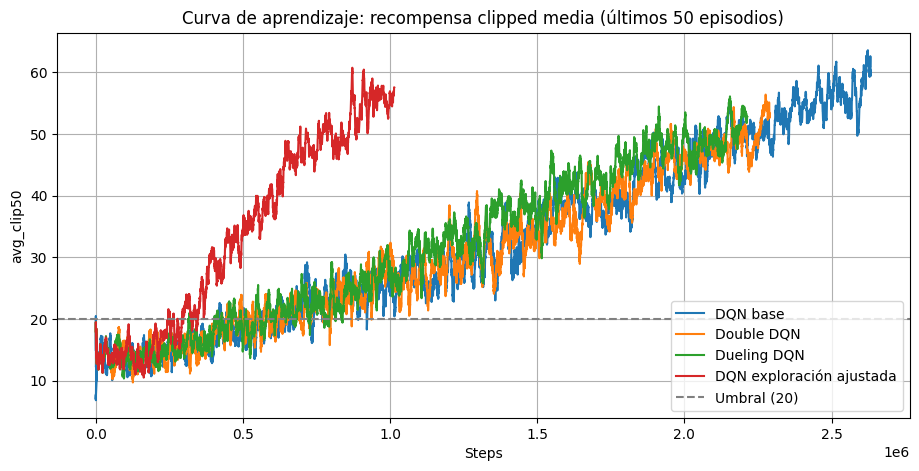

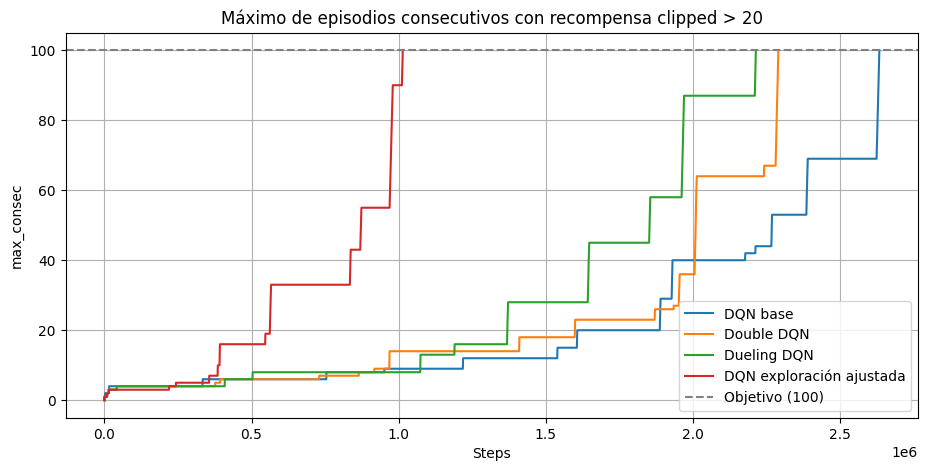

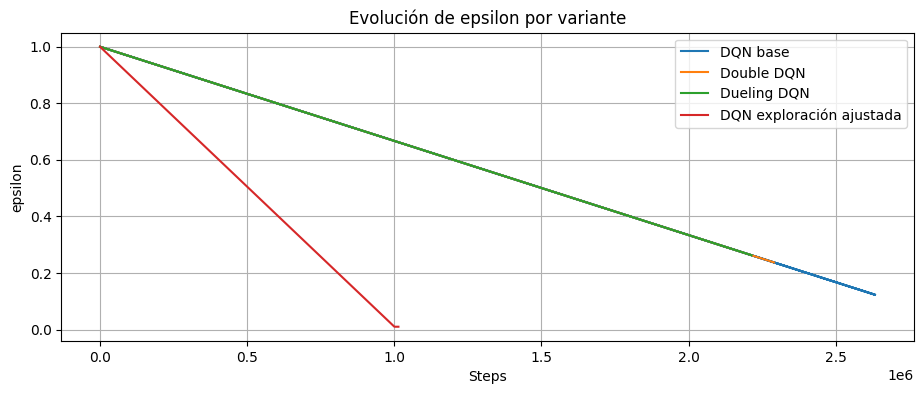

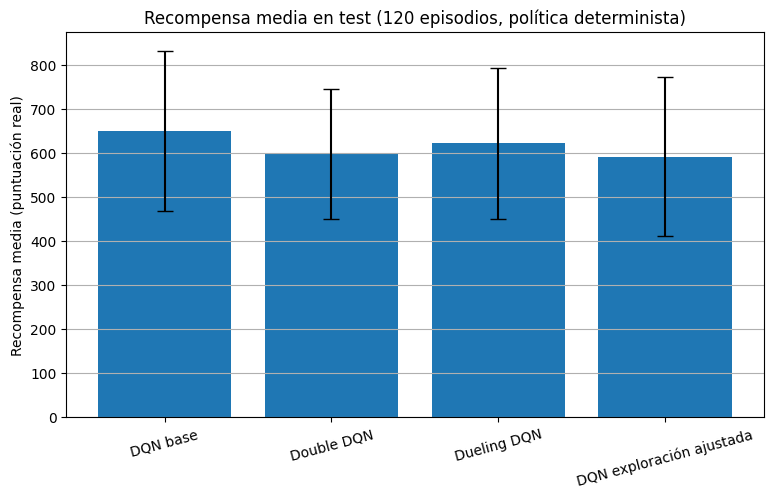

,variante,steps_totales,episodios,steps_hasta_avg20,steps_hasta_avg40,mejor_avg_clip50,max_consec,test_media,test_std,test_max
0,DQN base,2633424,11961,338,1557345,63.61,100,650.583333,181.982352,1295.0
1,Double DQN,2290139,10808,411061,1294769,56.41,100,598.416667,147.303518,1280.0
2,Dueling DQN,2213601,10634,314826,1370016,56.12,100,621.958333,170.968194,1430.0
3,DQN exploración ajustada,1014048,4475,245690,544860,60.77,100,591.375000,180.656168,1400.0


In [ ]:
# ============================
# M9. Comparativa: curvas, test y tabla resumen
# ============================

if 'test_results' not in globals():
    test_results = {}

dfs = {}
for run_name in RUN_NAMES:
    csv_path = RUN_PATHS[run_name]['csv']
    if csv_path.exists():
        dfs[run_name] = pd.read_csv(csv_path)
    else:
        print('Sin log de entrenamiento todavía:', run_name)

# --- Gráfica 1: curvas de aprendizaje ---
plt.figure(figsize=(11, 5))
for run_name, df_run in dfs.items():
    plt.plot(df_run['total_steps'], df_run['avg_clip50'], label=RUN_LABELS[run_name])
plt.axhline(CONSECUTIVE_THRESHOLD, linestyle='--', color='gray', label='Umbral (20)')
plt.title('Curva de aprendizaje: recompensa clipped media (últimos 50 episodios)')
plt.xlabel('Steps')
plt.ylabel('avg_clip50')
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfica 2: progreso hacia el criterio de éxito ---
plt.figure(figsize=(11, 5))
for run_name, df_run in dfs.items():
    plt.plot(df_run['total_steps'], df_run['max_consecutive_clipped_over_20'], label=RUN_LABELS[run_name])
plt.axhline(TARGET_CONSECUTIVE_EPISODES, linestyle='--', color='gray', label='Objetivo (100)')
plt.title('Máximo de episodios consecutivos con recompensa clipped > 20')
plt.xlabel('Steps')
plt.ylabel('max_consec')
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfica 3: schedules de exploración ---
plt.figure(figsize=(11, 4))
for run_name, df_run in dfs.items():
    plt.plot(df_run['total_steps'], df_run['exploration_rate'], label=RUN_LABELS[run_name])
plt.title('Evolución de epsilon por variante')
plt.xlabel('Steps')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfica 4: recompensa media en test ---
if len(test_results) > 0:
    names = [RUN_LABELS[k] for k in test_results]
    means = [test_results[k]['mean'] for k in test_results]
    stds = [test_results[k]['std'] for k in test_results]

    plt.figure(figsize=(9, 5))
    plt.bar(names, means, yerr=stds, capsize=6)
    plt.title('Recompensa media en test (120 episodios, política determinista)')
    plt.ylabel('Recompensa media (puntuación real)')
    plt.xticks(rotation=15)
    plt.grid(True, axis='y')
    plt.show()
else:
    print('Aún no hay resultados de test que graficar.')

# --- Tabla resumen ---
def steps_to_reach(df_run, threshold):
    hits = df_run[df_run['avg_clip50'] >= threshold]
    return int(hits['total_steps'].iloc[0]) if len(hits) else None

rows = []
for run_name, df_run in dfs.items():
    res = test_results.get(run_name, {})
    rows.append({
        'variante': RUN_LABELS[run_name],
        'steps_totales': int(df_run['total_steps'].iloc[-1]),
        'episodios': len(df_run),
        'steps_hasta_avg20': steps_to_reach(df_run, 20),
        'steps_hasta_avg40': steps_to_reach(df_run, 40),
        'mejor_avg_clip50': float(df_run['avg_clip50'].max()),
        'max_consec': int(df_run['max_consecutive_clipped_over_20'].max()),
        'test_media': res.get('mean'),
        'test_std': res.get('std'),
        'test_max': res.get('max'),
    })

summary = pd.DataFrame(rows)
display(summary)


---
# PARTE 3. Justificación de los parámetros seleccionados y de los resultados obtenidos

## 3.1. Entorno y preprocesado

El preprocesado replica el pipeline clásico de DQN para Atari (Mnih et al., 2015), aplicado automáticamente por `make_atari_env`:

| Elemento | Valor | Justificación |
|---|---|---|
| Escala de grises + resize | 84×84 | El color no aporta información decisiva en Space Invaders, y reducir de 210×160×3 a 84×84×1 divide el coste computacional de la red por ~9 |
| Pila de frames | 4 | Una imagen estática no contiene velocidades ni direcciones (proyectiles, desplazamiento de los invasores); el stack de 4 frames restaura aproximadamente la propiedad de Markov del estado |
| Frame-skip (`MaxAndSkipEnv`) | 4 | Repite cada acción durante 4 frames y toma el máximo píxel a píxel de los 2 últimos (elimina el parpadeo de sprites típico de Atari); acelera la simulación ~4× sin pérdida de control efectivo |
| Clipping de recompensa | [-1, 1] en entrenamiento | Homogeneiza la escala de los targets y estabiliza el gradiente (técnica estándar del paper de Nature) |
| `FireResetEnv` | — | Ejecuta FIRE automáticamente al inicio del episodio, necesario para que la partida arranque |

**Aclaración sobre la métrica `clip` de los logs:** es `recompensa_real / 10`, una convención interna del proyecto para seguir el entrenamiento con números comparables a la práctica anterior; **no** es el clipping ±1 de Atari (que sí se aplica internamente durante el entrenamiento). En **test** se usa el entorno sin clipping y se reporta la **puntuación real** del juego, que es lo que exige el enunciado.

## 3.2. Red neuronal

Arquitectura convolucional del DQN de Nature (Mnih et al., 2015), implementada como `features_extractor` de SB3 (`CustomCNN84`) con `net_arch=[]` para que la única capa posterior al extractor sea la cabeza lineal Q:

| Capa | Configuración | Salida | Parámetros |
|---|---|---|---|
| Conv1 | 32 filtros 8×8, stride 4, ReLU | 20×20×32 | 8.224 |
| Conv2 | 64 filtros 4×4, stride 2, ReLU | 9×9×64 | 32.832 |
| Conv3 | 64 filtros 3×3, stride 1, ReLU | 7×7×64 | 36.928 |
| Flatten + Dense | 3136 → 512, ReLU | 512 | 1.606.144 |
| Cabeza Q | 512 → 6 (una salida por acción) | 6 | 3.078 |

En total ≈ 1,69 M de parámetros. Los strides grandes sustituyen al pooling (reducen resolución preservando información espacial aprendible), y la red produce las 6 Q-values en una sola pasada, lo que permite el `argmax` de la política greedy con una única inferencia.

## 3.3. Hiperparámetros del DQN base

| Parámetro | Valor | Justificación |
|---|---|---|
| `learning_rate` | 1e-4 | Valor de referencia para Adam en DQN-Atari; con lr mayores la pérdida de Huber oscila y desestabiliza los targets |
| `buffer_size` | 100.000 | Compromiso entre diversidad de experiencias y RAM de Colab (~2,8 GB en uint8 con frames 84×84×4) |
| `learning_starts` | 50.000 | Llena el buffer con experiencia (mayoritariamente aleatoria) antes de la primera actualización, evitando sobreajustar a las primeras transiciones |
| `batch_size` | 32 | Valor del paper original: batches pequeños con muchas actualizaciones funcionan bien en DQN |
| `gamma` | 0,99 | Horizonte efectivo de ~100 steps, suficiente para conectar causalmente un disparo con su impacto |
| `train_freq` | 4 | Una actualización de gradiente por cada 4 steps de entorno (ratio del paper) |
| `target_update_interval` | 10.000 | La red target congelada estabiliza los targets del TD-error |
| ε: 1.0 → 0.001 (lineal, 30 % de 10M) | schedule lineal | Exploración intensa al principio, explotación progresiva |
| Criterio de parada | 100 episodios consecutivos con clip > 20 | Exige consistencia: no basta con un episodio bueno aislado |

## 3.4. Resultados del DQN base

- El entrenamiento se detuvo por el **criterio de éxito** tras ~2,63M steps y ~11.930 episodios: 100 episodios consecutivos con recompensa clipped > 20.
- Mejor media móvil `avg_clip50` = **63,6** (equivalente a ~636 puntos reales); ε final ≈ 0,123.
- **Test (120 episodios, política determinista): media = 662,25 puntos**, máximo = 1.405. El requisito del listado del grupo —**alcanzar más de 20 puntos con reward clipping durante más de 100 episodios consecutivos**— se cumple por partida doble: durante el entrenamiento el agente encadenó 100 episodios consecutivos con recompensa clipped > 20 (es precisamente el criterio de parada implementado), y en modo test la media equivale a ~66 puntos clipped, más del triple del umbral. Las cuatro configuraciones de la Parte 2 satisfacen igualmente el requisito: todas alcanzaron los 100 episodios consecutivos y obtienen medias de test de 59-65 puntos clipped.
- La curva de aprendizaje muestra tres fases: (i) hasta ~0,5M steps, mejora lenta mientras domina la exploración; (ii) entre 0,5M y 2M, crecimiento sostenido de `avg_clip50` (de ~10 a ~50) a medida que ε decae; (iii) a partir de ~2M, consistencia suficiente para encadenar los 100 episodios del criterio.
- Un detalle relevante: el agente alcanzó el criterio **explorando todavía al 12 %**. La política greedy subyacente era mejor de lo que reflejaban los episodios de entrenamiento, y por eso el test determinista (662 puntos de media) supera a la media móvil de entrenamiento (~600). Esta observación es precisamente la que motiva la Propuesta 3.

## 3.5. Discusión de las tres propuestas

**Propuesta 1 — Double DQN.**
*Qué esperamos:* al eliminar el sesgo de sobreestimación del `max`, los targets son más realistas y el aprendizaje más estable. En la literatura (van Hasselt et al., 2016) Double DQN iguala o supera a DQN en la gran mayoría de juegos de Atari, con ganancias moderadas en Space Invaders.
*Resultado obtenido:* Double DQN alcanzó el criterio de éxito en **2,29M steps frente a los 2,63M del base (−13 %)**, y llegó antes a un nivel de juego alto (avg_clip50 ≥ 40 en 1,29M steps frente a 1,56M, −17 %). En el test de 120 episodios obtuvo una media de **598,4 puntos con la desviación típica más baja de las cuatro configuraciones (147,3, un 19 % menos dispersión que el base)**. Es decir: aprendió algo más rápido y juega de forma más *consistente*, exactamente el efecto que predice la corrección del sesgo de sobreestimación (van Hasselt et al., 2016). Su media de test queda por debajo de la del base (650,6), pero el base entrenó un 15 % más de steps y la diferencia (~52 puntos) es del orden de 3 errores estándar con una sola semilla, por lo que no puede considerarse concluyente.

**Propuesta 2 — Dueling DQN.**
*Qué esperamos:* mejor eficiencia de muestras, porque cada actualización mejora la estimación de `V(s)` compartida por todas las acciones. Wang et al. (2016) reportan una de las mayores mejoras relativas precisamente en Space Invaders, donde abundan los estados en los que la acción concreta importa poco.
*Resultado obtenido:* Dueling fue la más eficiente de las dos mejoras algorítmicas: criterio en **2,21M steps (−16 % vs. base)** y el arranque más rápido de las variantes con schedule estándar (avg_clip50 ≥ 20 en 315k steps, frente a 411k de Double). En test logró la **segunda mejor media (622,0 ± 171,0)** y el **mejor episodio individual de todo el estudio (1.430 puntos)**. El resultado es coherente con Wang et al. (2016), que reportan ganancias de eficiencia especialmente grandes en Space Invaders: al aprender V(s) compartido entre acciones, cada actualización aprovecha más la experiencia en los (muchos) estados donde la acción concreta importa poco.

**Propuesta 3 — Exploración ajustada.**
*Qué esperamos:* una subida más temprana de la curva de aprendizaje al empezar a explotar antes (el annealing termina en ~1M steps en lugar de seguir al 12 % de aleatoriedad a los 2,6M). Los target updates más frecuentes (5k) aceleran la propagación de lo aprendido con un leve coste de estabilidad. El riesgo de esta propuesta es converger prematuramente a una política subóptima por falta de exploración tardía.
*Resultado obtenido:* el efecto más espectacular del estudio: criterio de éxito en **1,01M steps, 2,6 veces menos que el base**, y nivel alto de juego (avg_clip50 ≥ 40) en solo 545k steps frente a 1,56M (2,9×). La curva de aprendizaje (gráfica 1 de M9) se despega de las demás desde ~250k steps. Como contrapartida, su media de test es la más baja (591,4 ± 180,7), con dos explicaciones honestas: (i) al parar tan pronto acumuló ~246k actualizaciones de gradiente frente a ~645k del base — su política final está menos refinada; y (ii) el criterio de parada no es del todo comparable entre schedules: esta variante encadenó sus 100 episodios jugando con ε = 0,01 (sin apenas ruido en contra), mientras que base, Double y Dueling lo lograron explorando aún al 12-26 %, un mérito adicional que el criterio no captura.

## 3.6. Comparativa global y conclusiones

**1. Eficiencia de muestras.** Las tres propuestas superan al DQN base: exploración ajustada (1,01M steps hasta el criterio) ≪ Dueling (2,21M) ≈ Double (2,29M) < base (2,63M). Con el umbral avg_clip50 ≥ 40, el orden se mantiene (545k / 1,37M / 1,29M / 1,56M). Nota metodológica: el valor `steps_hasta_avg20 = 338` del base es un artefacto de la media móvil de 50 episodios en el arranque (pocos episodios en la ventana), por lo que usamos el umbral 40 como métrica robusta de eficiencia.

**2. Rendimiento final.** El base obtiene la mejor media de test (650,6), seguido de Dueling (622,0), Double (598,4) y tuned (591,4). Pero estas diferencias deben leerse con cautela: el error estándar de cada media es de ±13-17 puntos (std ~147-182 sobre 120 episodios), hay una única semilla, y el diseño experimental iguala la *competencia* alcanzada (todas paran al mismo criterio), no el presupuesto: el base entrenó entre un 15 % y un 160 % más que las demás. La lectura correcta no es "el base es mejor", sino que **las tres mejoras alcanzan un rendimiento final comparable con un coste de entrenamiento sustancialmente menor**. Las cuatro configuraciones superan holgadamente el requisito mínimo del enunciado.

**3. Estabilidad.** Ninguna variante muestra colapsos ni oscilaciones patológicas en sus curvas. Double DQN es la más consistente en test (std 147,3 frente a 171-182 del resto), en línea con la teoría: targets menos sobreestimados producen una política de calidad más uniforme. Dueling combina consistencia razonable con los mejores episodios pico (máx. 1.430).

**4. Coherencia con la literatura.** El orden esperado en eficiencia (Dueling ≥ Double ≥ DQN) se reproduce, incluida la ventaja de Dueling en Space Invaders que reportan Wang et al. (2016). La sorpresa aparente —que ninguna mejora supere al base en media de test— desaparece al considerar el presupuesto: con parada por criterio de competencia, las mejoras convierten su ventaja en *ahorro de cómputo* en lugar de en puntuación final. Un experimento complementario natural sería la comparación a presupuesto fijo (mismos steps para todas), donde la literatura predice que las mejoras superarían también la puntuación del base.

**Conclusión.** Se entrega como mejor modelo el **DQN base (media de test 650,6 con política determinista)**, si bien el resultado central del estudio es que las tres propuestas alcanzan una competencia equivalente con hasta 2,6× menos interacciones con el entorno — en un problema real, donde la experiencia es cara, la variante de exploración ajustada sería la elección preferible.

## 3.7. Limitaciones y trabajo futuro

- **Una sola semilla (42) por variante**, por limitación de cómputo: las diferencias pequeñas entre variantes no son estadísticamente concluyentes. Lo riguroso serían 3–5 semillas por variante y reportar media ± desviación entre semillas.
- Las mejoras se han evaluado **por separado** para aislar su efecto; combinarlas (al estilo Rainbow, Hessel et al., 2018), junto con Prioritized Experience Replay y n-step returns, sería la continuación natural.
- La **parada temprana** al alcanzar el criterio favorece comparar eficiencia de muestras, pero no el rendimiento asintótico: con más presupuesto las conclusiones podrían cambiar.
- El test usa una única configuración (120 episodios deterministas con la misma semilla de entorno); una evaluación más robusta usaría semillas de test distintas de la de entrenamiento.

## Referencias

- Mnih, V. et al. (2015). *Human-level control through deep reinforcement learning*. Nature, 518, 529–533.
- van Hasselt, H., Guez, A., Silver, D. (2016). *Deep Reinforcement Learning with Double Q-learning*. AAAI.
- Wang, Z. et al. (2016). *Dueling Network Architectures for Deep Reinforcement Learning*. ICML.
- Hessel, M. et al. (2018). *Rainbow: Combining Improvements in Deep Reinforcement Learning*. AAAI.
